## Simulation of Hofsadter Butterfly

In [17]:
import numpy as np
from math import comb
from tabulate import tabulate
import matplotlib.pyplot as plt
from itertools import combinations
import scipy.linalg as la
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors 
import math
from sympy import *
from fractions import Fraction 

### parameters of the simulation

In [18]:
size=12
PBC=False
T_x=1
T_y=1
p=1
q=3
N=1 #number of particles

single_cherns_plot_with_OBC=False#this just a curiosity to plot individual chern number, comment if is useless


### State from labels, double and single index dictionary

In [19]:
def get_single_index_from_double(n,m, size=size): #n is column, m is row
    index=m*size+n
    return index

def get_double_index_from_single(index, size=size):
    n=index % size
    m=index//size 
    return n,m

### Get state from labels and viceversa

In [20]:
def get_state_from_label(state_number, size=size):
    state=np.zeros(size**2, dtype=bool)
    for i in range((size**2-1), -1, -1):
        if state_number >= (2**i):
            state[i] = True
            state_number=state_number - (2**i)
    return state


def get_label_from_state(state, size=size):
    state_number=0
    for i in range(size**2-1, -1, -1):
        if state[i]:
            state_number += 2**i
    return state_number

def get_double_index_state_from_label(state_number, size=size):
    state=get_state_from_label(state_number, size=size)
    double_index_state=np.zeros((size,size), dtype=bool)
    for i in range(size):
        for j in range(size):
            double_index_state[i,j]=state[get_single_index_from_double(i,j, size=size)]
    return double_index_state


def get_state_of_fixed_electron_number(i, N, size):  #this funciton does not require to allocate the whole dictionary. Using this or not depends if problem is memory or computation time
                                                          #could maybe replase this funciton with list(combinations(range(size**2), N)); check which is more efficient
    """                                                   
    Finds the i-th integer (0-indexed) with exactly N set bits (ones).

    Args:
        i (int): The 0-based index of the desired number in the lexicographical order.
        N (int): The number of set bits (ones) the number must have.
        size (int): The grid size, determining the total number of bits (size*size).
    """
    total_bits = size**2

    if not (0 <= N <= total_bits and i >= 0):
        raise ValueError("N must be between 0 and total_bits, and index i must be non-negative.")

    # Check if the index is valid. The number of ways to choose N bits
    # from total_bits is the total number of valid states.
    total_combinations = comb(total_bits, N)
    if i >= total_combinations:
        raise ValueError(f"Index {i} is out of range. For N={N}, the max index is {total_combinations - 1}.")

    result = 0
    # Iterate from the most significant bit to the least
    for bit in range(total_bits - 1, -1, -1):
        if N == 0:
            break

        # If we must place a '1' here because the number of remaining bits
        # equals the number of ones we still need to place.
        if N == bit + 1:
            result |= (1 << (bit + 1)) - 1 # Set all remaining bits to 1
            break

        # Calculate the number of combinations that would have a '0' at this bit (talking about the bit corresponding to bit+1).
        # This is the number of ways to choose N ones from the remaining 'bit' positions.
        combinations_with_zero = comb(bit, N)

        if i < combinations_with_zero:
            # The i-th number is within the block of numbers that have a '0'
            # at this position. So we place a '0' (i.e., do nothing).
            pass
        else:
            # The i-th number is in the block that has a '1' at this position.
            result |= (1 << bit)  # Place a '1'
            i -= combinations_with_zero  # Subtract the combinations we skipped
            N -= 1  # One less '1' to place
    state = get_state_from_label(result, size=size)
    #print(f"Label: {get_label_from_state(state, size=size)}")
    return state


def get_number_of_states_per_fixed_number(N, size):
    fixed_size=comb(size**2 , N)
    return fixed_size


def get_state_list(N, size):
    
    #build the labeled state list
    fixed_size=get_number_of_states_per_fixed_number(N, size)
    state_list = [None] * fixed_size  # Initialize state_list with the appropriate size
    for i in range(fixed_size):
        state_list[i] = get_state_of_fixed_electron_number(i, N=N, size=size) ##crea inversa della funzione se vedi che questo è bottleneck

    return state_list

### Functions to calcualte topology

In [21]:
def get_occupied_vectors( num_occupied_states, eigenvectors):
    occupied_vectors=[]
    # eigenvalues, eigenvectors=np.linalg.eigh(get_hamiltonian_for_fixed_number_of_electrons(N, PBC, T_y, T_x, p, q))
    occupied_vectors= eigenvectors[:, :(num_occupied_states)] 
    #P = occupied_vectors @ occupied_vectors.T.conj()
    # print(f"Occupied vectors shape: {occupied_vectors.shape}")
    # print(eigenvectors)
    return occupied_vectors

def get_U_V_matrices(N=N,size=size):
    fixed_number=get_number_of_states_per_fixed_number(N=N, size=size)
    u_1p = [complex(m, 0) for m in range(size) for n in range(size)]
    v_1p = [complex(n, 0) for m in range(size) for n in range(size)]
    N_particle_basis = list(combinations(range(size**2), N))                      ###DA IMPLEMENTARE SOPRA FORSE
    U_1 = np.array([sum(u_1p[p] for p in state) for state in N_particle_basis])
    V_1=  np.array([sum(v_1p[p] for p in state) for state in N_particle_basis])
    U = np.diag(np.exp(1j * 2 * np.pi * U_1 / size))
    V = np.diag(np.exp(1j * 2 * np.pi * V_1 / size))
    return U, V

def get_chern_number(num_occupied_states,eigenvectors, N=N, size=size):
    U_tilde, V_tilde = get_U_V_matrices(N=N, size=size)
    occupied_vectors = get_occupied_vectors( num_occupied_states, eigenvectors)
    #I = np.identity((get_number_of_states_per_fixed_number(N, size)), dtype=complex)
    U_proj = occupied_vectors.T.conj() @ U_tilde @ occupied_vectors
    V_proj = occupied_vectors.T.conj() @ V_tilde @ occupied_vectors
    Bott_matrix = V_proj @ U_proj @ V_proj.T.conj() @ U_proj.T.conj()
    eigvals = la.eigvals(Bott_matrix)
    chern_number = np.sum(np.angle(eigvals)) / (2 * np.pi)

    return chern_number


def analyze_topology_at_flux(eigenvalues, eigenvectors,q, N, size, print_chern=False):
    """
    Analyzes a single Hamiltonian to find its stable Chern invariants
    by identifying the q-1 largest energy gaps.
    """ 
    #THIS FUNCTION IS CONCEPTUALLY CORRECT ONLY WHEN p/q IS A REDUCED FRACTION WITH BOT p and q PRIMES. Only in this case we know there are q-1 gaps and q bands.
    
    # --- This section is now updated with your improved logic ---
    if q > 1:
        gaps = np.diff(eigenvalues)
        # Find the indices of the q-1 largest gaps in the spectrum
        major_gap_indices = np.argsort(gaps)[-(q-1):]
    else:
        # If q=1, there is only one band and no gaps.
        major_gap_indices = np.array([], dtype=int)

    # Calculate Chern number ONLY at these major gaps
    chern_at_gaps = {}
    for k_gap in major_gap_indices:
        num_occupied = k_gap + 1
        chern_num = get_chern_number(num_occupied_states=num_occupied, eigenvectors=eigenvectors, N=N, size=size)
        print(f"Chern number at gap {k_gap}: {chern_num}")
        chern_at_gaps[num_occupied] = chern_num#round(chern_num)
        
    num_eigenvalues = len(eigenvalues)
    chern_assignments = np.zeros(num_eigenvalues, dtype=float)
    
    current_chern = 0
    sorted_gap_keys = sorted(chern_at_gaps.keys()) #get umber of occupied states at each band
    
    start_index = 0
    for num_occupied in sorted_gap_keys:
        # Assign the current Chern number to the states in the band
        chern_assignments[start_index:num_occupied] = current_chern
        # Update the Chern number for the next band
        current_chern = chern_at_gaps[num_occupied]
        start_index = num_occupied
        
    # Assign the final Chern number to the last band
    chern_assignments[start_index:] = current_chern
            
    return chern_assignments


### Hamiltonian

#### $H=T(\sum_{<i,j>}e^{i\theta_{n,m}}c^{\dag}_{n^{\prime},m^{\prime}}c_{n,m}+h.c.)$ with $\theta_{m,n}=\frac{e}{\hbar}\int_{m,n}^{m\prime,n\prime}A\cdot dl$

#### function needed to build hamiltonian

In [22]:
def get_phases(q=q,p=p, size=size):
    if size%q != 0:
        raise ValueError("Size must be divisible by q") #condition can be relaxed when not using PBC, do in the future
    else:
        phases=np.zeros(q, dtype=complex)
        for i in range(q):
            phases[i] = np.exp(-2j * p * np.pi * i / q)
    return phases  
    

def reduce_array_for_periodicity(state, shift, q=q, size=size): #this takes the full array value and contracts by column, shift is the step in the periodicty to account for
    reduced_state=np.zeros((size//q,size), dtype=bool)
    for i in range(size//q):
        for j in range(size):
            reduced_state[i,j]= state[i*q+shift,j]
    return reduced_state


def check_if_occupied(n,m,state): ## check if the site (n,m) is occupied
    if state[get_single_index_from_double(n,m)] == True:
        return True
    else:
        return False
    

def calculate_IPR(vector): #Inverse Participation Ratio to filter out edge states in OBC
    vector = np.abs(vector) ** 2
    ipr = np.sum(vector ** 2)
    return ipr


def find_index_of_state(state_list, target_state):
    #print(target_state)
    for temp, state in enumerate(state_list):
        if np.array_equal(state, target_state): 
            return temp
    return -1

#### Building Full Hamiltonain (kinda useless)

In [23]:

    
def get_full_hamiltonian(size=size, PBC=PBC, T_y=T_y, T_x=T_x, p=p, q=q, progress_bar=False):
    H=np.zeros((2**(size**2), 2**(size**2)),dtype=complex)
    phases= get_phases(q, p,size=size)

    t=0
    for i in range(2**(size**2)):
        if progress_bar:    
            t=t+1
            print(f"Processing state {t}/{2**(size**2)}")     #uncomment for progress bar

        ket_state = get_state_from_label(i, size=size)
        #print("ket_state:", ket_state)
        ket_state_double = get_double_index_state_from_label(get_label_from_state(ket_state, size=size), size=size)

        for period_index in range(len(phases)):
            
            
            reduced_state = reduce_array_for_periodicity(ket_state_double, period_index, q)
            for k in ([-1,+1]): ##drop the minus one if the you want to add the conjugate
                bra_state = np.zeros(size**2, dtype=bool)
                #check=False      ##this is to avoid putting bra kets with all zeroes
                for index1 in range(size//q):
                    for index2 in range(size):
                        if reduced_state[index1,index2]==True:
                            check=True
                            n=index1*q+period_index
                            m=index2

                            bra_state = ket_state.copy() 
                            bra_state[get_single_index_from_double(n,m)]=False
                            if PBC:
                                m_k = (m + k) % size
                            else:
                                m_k = m + k
                                if m_k < 0 or m_k > size-1:
                                    continue
                            if check_if_occupied(n,m_k,ket_state): ##two fermionic creation operators give zero, this allow to exclude those cases
                                continue
                            bra_state[get_single_index_from_double(n,m_k)]=True
                        #if check:
                            H[get_label_from_state(ket_state), get_label_from_state(bra_state)] = -(phases[period_index])**(k) * T_y
                    # print("ket_state:", ket_state)
                    # print("bra_state:", bra_state)
            

        
        for k in ([-1,+1]):             
            for index in range(len(ket_state)):
                bra_state = np.zeros(size**2, dtype=bool)
                if ket_state[index]==True:   
                    (n,m)= get_double_index_from_single(index)  
                    bra_state = ket_state.copy() 
                    bra_state[get_single_index_from_double(n,m)]=False
                    if PBC:
                        n_k = (n + k) % size
                    else:
                        n_k = n + k
                        if n_k < 0 or n_k > size-1:
                            continue
                    if check_if_occupied(n_k,m,ket_state):
                        continue
                    bra_state[get_single_index_from_double(n_k, m)] = True
                    H[get_label_from_state(ket_state), get_label_from_state(bra_state)] = -T_x
    return H

#H=np.conjugate(H.T)+H# THIS IS HORRIBLY INEFFICENT, FUCK YOU NUMPY
# print("Hamiltonian H:", H)
# print("Hamiltonian H shape:", H.shape)

#### Hamiltonian per fixed number of particle

In [24]:
def get_hamiltonian_for_fixed_number_of_electrons( N, state_list , PBC=PBC, T_y=T_y, T_x=T_x, p=p, q=q, progress_bar=False, size=size):
    
    fixed_size=get_number_of_states_per_fixed_number(N=N, size=size)
    H=np.zeros((fixed_size, fixed_size),dtype=complex)
    phases= get_phases(q, p,size=size)

    t=0
    for i in range(fixed_size):
        if progress_bar:    
            t=t+1
            print(f"Processing state {t}/{fixed_size}")     #uncomment for progress bar

        ket_state=state_list[i]
        #print("ket_state:", ket_state)
        ket_state_double = get_double_index_state_from_label(get_label_from_state(ket_state, size=size), size=size)

        for period_index in range(len(phases)):
            
            
            reduced_state = reduce_array_for_periodicity(ket_state_double, period_index, q)
            for k in ([-1,+1]): ##drop the minus one if the you want to add the conjugate
                bra_state = np.zeros(size**2, dtype=bool)
                #check=False      ##this is to avoid putting bra kets with all zeroes
                for index1 in range(size//q):
                    for index2 in range(size):
                        if reduced_state[index1,index2]==True:
                            check=True
                            n=index1*q+period_index
                            m=index2

                            bra_state = ket_state.copy() 
                            bra_state[get_single_index_from_double(n,m)]=False
                            if PBC:
                                m_k = (m + k) % size
                            else:
                                m_k = m + k
                                if m_k < 0 or m_k > size-1:
                                    continue
                            if check_if_occupied(n,m_k,ket_state): ##two fermionic creation operators give zero, this allow to exclude those cases
                                continue
                            bra_state[get_single_index_from_double(n,m_k)]=True
                        #if check:
                            H[find_index_of_state(state_list,bra_state),i] = -(phases[period_index])**(k) * T_y
                    # print("ket_state:", ket_state)
                    # print("bra_state:", bra_state)
            

        
        for k in ([-1,+1]):             
            for index in range(len(ket_state)):
                bra_state = np.zeros(size**2, dtype=bool)
                if ket_state[index]==True:   
                    (n,m)= get_double_index_from_single(index)  
                    bra_state = ket_state.copy() 
                    bra_state[get_single_index_from_double(n,m)]=False
                    if PBC:
                        n_k = (n + k) % size
                    else:
                        n_k = n + k
                        if n_k < 0 or n_k > size-1:
                            continue
                    if check_if_occupied(n_k,m,ket_state):
                        continue
                    bra_state[get_single_index_from_double(n_k, m)] = True
                    H[find_index_of_state(state_list,bra_state),i] = -T_x
    return H



### Building Butterfly 

In [25]:
#this is to create my data
def get_energy_bands_per_flux(N=N, size=size, PBC=PBC, T_y=T_y, T_x=T_x):

    #build the labeled state list
    state_list= get_state_list(N=N, size=size) ##crea inversa della funzione se vedi che questo è bottleneck


    chern_classes=[]
    energies = []
    fluxes = []
    ipr_eigenvectors = []
    single_cherns_OBC = []
    for denominator in range(1, (size // 2) + 1):
        if size % denominator == 0:
            for numerator in range(0, denominator + 1):
                if math.gcd(numerator, denominator) == 1: #if not interested in chern number, uncomment this and comment the next line
                #if isprime(numerator) and isprime(denominator):  # Check if both numerator and denominator are prime, needed to calcualte just chern number
                    chern_assignments = []
                    eigenvalues, eigenvectors = np.linalg.eigh(get_hamiltonian_for_fixed_number_of_electrons( N=N, state_list=state_list, PBC=PBC, T_y=T_y, T_x=T_x, p=numerator, q=denominator, progress_bar=False))

                    print(f" Cherns at {numerator}/ {denominator}") #this only to be sure that the gaps choosen are correct and cherns are integers
                    chern_assignments = analyze_topology_at_flux(N=N, size=size, eigenvalues=eigenvalues, eigenvectors=eigenvectors, q=denominator, print_chern=True) 
                    chern_classes.append(chern_assignments)
                    energies.append(eigenvalues)
                    fluxes.append(numerator / denominator)

                    if PBC == False:                                #Calculate IPR only for OBC
                        ipr_eigenvectors.append([calculate_IPR(eigenvectors[:, i]) for i in range(eigenvectors.shape[1])])
                    
                        if single_cherns_plot_with_OBC: #this just a curiosity to plot individual chern number, comment if is useless
                            #this just a curiosity to plot individual chern number, comment if is useless
                            chern_per_flux_OBC=[]
                            chern_per_flux_OBC.append(0) #fixes firts
                            for k in range(1, len(eigenvalues)-1): #this just a curiosity to plot individual chern number, comment is useless
                                chern_OBC=get_chern_number(num_occupied_states=k, eigenvectors=eigenvectors, N=N, size=size)
                                chern_per_flux_OBC.append(chern_OBC)
                            chern_per_flux_OBC.append(0) #fixes last            
                            single_cherns_OBC.append(chern_per_flux_OBC)

    return fluxes, np.array(energies), np.array(ipr_eigenvectors), np.array(chern_classes), np.array(single_cherns_OBC)





# Generate the Hofstadter butterfly with Aubry-Andrè model
def generate_hofstadter_butterfly(resolution=400, size=size, PBC=PBC, T_y=T_y, T_x=T_x):
    fluxes = np.linspace(0, 1, resolution)  # Flux values from 0 to 1
    k_y_values = np.linspace(0, 2 * np.pi, size, endpoint=False) #endpoint False beacuse 0 and 2pi are equal
    all_energies = []
    for alpha in fluxes:
        energies_for_alpha = []
        for k_y in k_y_values: #this is the conserved momentum in the y-direction. Usual butterfly is plotted with k_y=0, that why we see only (size) eigenvalues
            hamiltonian = np.zeros((size, size)) # Matrix is real, complex type not needed
            if PBC:
                for i in range(size):
                    # Hopping terms
                    hamiltonian[i, (i + 1) % size] = -T_x
                    hamiltonian[(i + 1) % size, i] = -T_x
                    # On-site potential
                    hamiltonian[i, i] = -(2*T_y) * np.cos(2 * np.pi * alpha * i +k_y)
            else:
                for i in range(size):
                    # Hopping terms for Open Boundary Conditions
                    if i < size - 1:
                        hamiltonian[i, i + 1] = -T_x
                        hamiltonian[i + 1, i] = -T_x
                        # On-site potential
                        hamiltonian[i, i] = -(2*T_y) * np.cos(2 * np.pi * alpha * i+k_y)


            eigvals = np.linalg.eigvalsh(hamiltonian)
            energies_for_alpha.extend(eigvals)
        
        all_energies.append(energies_for_alpha)
    return fluxes, np.array(all_energies)



### Execute the code

In [26]:
fluxes_hof, energies_hof = generate_hofstadter_butterfly(resolution=500)
fluxes_mydata, energies_mydata, ipr_values_mydata, chern_classes_mydata,single_cherns_OBC = get_energy_bands_per_flux(N=N, size=size, PBC=PBC, T_y=T_y, T_x=T_x)


# flatten the energy array and create a corresponding flux value for each energy point.
flux_array_hof = np.repeat(fluxes_hof, energies_hof.shape[1])
energy_array_hof = energies_hof.flatten()


 Cherns at 0/ 1
 Cherns at 1/ 1
 Cherns at 1/ 2
Chern number at gap 71: -9.762535897269961e-16


/var/folders/z4/q3_z78fj4gldz7hpcmkdj1y00000gn/T/ipykernel_18892/3938331849.py:25: RuntimeWarning: divide by zero encountered in matmul
  U_proj = occupied_vectors.T.conj() @ U_tilde @ occupied_vectors
/var/folders/z4/q3_z78fj4gldz7hpcmkdj1y00000gn/T/ipykernel_18892/3938331849.py:25: RuntimeWarning: overflow encountered in matmul
  U_proj = occupied_vectors.T.conj() @ U_tilde @ occupied_vectors
/var/folders/z4/q3_z78fj4gldz7hpcmkdj1y00000gn/T/ipykernel_18892/3938331849.py:25: RuntimeWarning: invalid value encountered in matmul
  U_proj = occupied_vectors.T.conj() @ U_tilde @ occupied_vectors
/var/folders/z4/q3_z78fj4gldz7hpcmkdj1y00000gn/T/ipykernel_18892/3938331849.py:26: RuntimeWarning: divide by zero encountered in matmul
  V_proj = occupied_vectors.T.conj() @ V_tilde @ occupied_vectors
/var/folders/z4/q3_z78fj4gldz7hpcmkdj1y00000gn/T/ipykernel_18892/3938331849.py:26: RuntimeWarning: overflow encountered in matmul
  V_proj = occupied_vectors.T.conj() @ V_tilde @ occupied_vectors
/va

 Cherns at 1/ 3
Chern number at gap 95: 0.9999999999999984
Chern number at gap 47: -1.000000000000002
 Cherns at 2/ 3
Chern number at gap 95: -1.0000000000000004
Chern number at gap 47: 1.0000000000000022
 Cherns at 1/ 4
Chern number at gap 36: -0.9999999999999996
Chern number at gap 37: -0.9999999999999984
Chern number at gap 105: 0.9999999999999981
 Cherns at 3/ 4
Chern number at gap 106: -1.0000000000000013
Chern number at gap 37: 1.0000000000000009
Chern number at gap 105: -0.9999999999999984
 Cherns at 1/ 6
Chern number at gap 119: 1.0000000000000022
Chern number at gap 118: 0.9999999999999993
Chern number at gap 24: -0.9999999999999989
Chern number at gap 117: 0.9999999999999991
Chern number at gap 25: -0.9999999999999993
 Cherns at 5/ 6
Chern number at gap 119: -1.0000000000000007
Chern number at gap 24: 0.9999999999999999
Chern number at gap 118: -0.9999999999999986
Chern number at gap 117: -1.0000000000000004
Chern number at gap 25: 1.0000000000000013


### Plotting results

#### Comparison of bands

In the case is setted PBC=False, so the system has OBC, we color of the dots correspond to the IPR. We can see how the crossing gap states are the edge states.

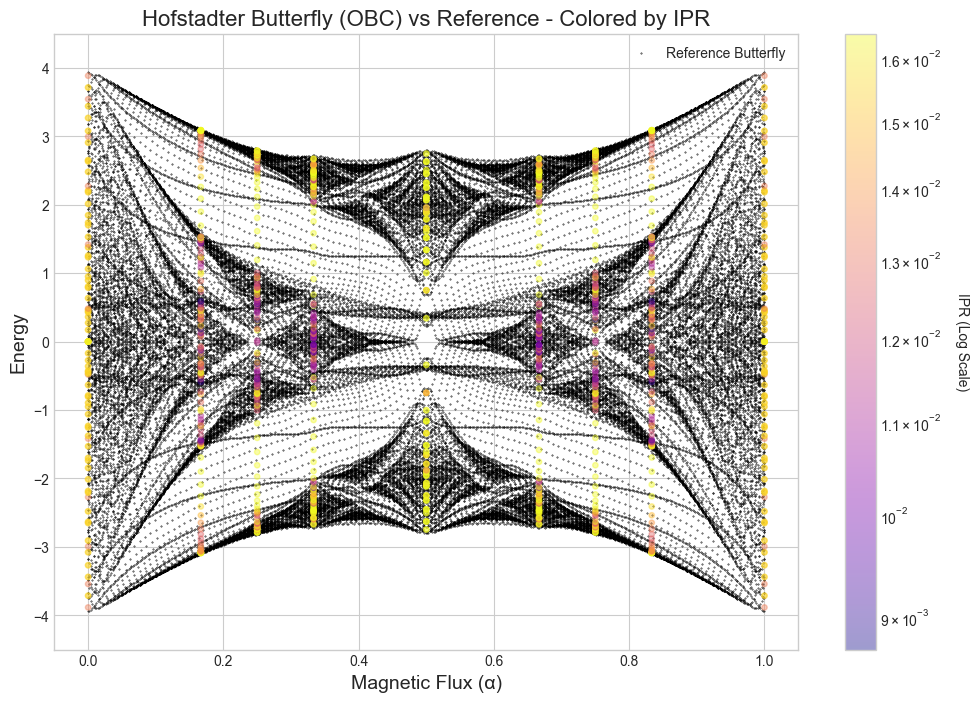

In [27]:


plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 8))


# This is plotted first, in black, as a fine-grained background.

plt.scatter(flux_array_hof, energy_array_hof, s=0.5, c='black', marker='.', label='Reference Butterfly')

# --- Plot 2: Calculated Data (Superimposed) ---
if PBC == True:
    flux_array_mydata = np.repeat(fluxes_mydata, energies_mydata.shape[1])
    energies_array_mydata = energies_mydata.flatten()
    
    plt.scatter(flux_array_mydata, energies_array_mydata, alpha=0.5, s=15, c='red', label='My Data (PBC)')
    plt.title("Hofstadter Butterfly (PBC) vs Reference", fontsize=16)

else: # This block handles the OBC case with IPR coloring
    #  Flatten the arrays to align each data point
    flux_array_mydata = np.repeat(fluxes_mydata, energies_mydata.shape[1])
    energies_array_mydata = energies_mydata.flatten()
    ipr_array_mydata = ipr_values_mydata.flatten()

    #  Use a logarithmic color scale for better visibility ---
    # add a small epsilon to vmin to avoid errors if the minimum IPR is zero.
    # gamma_val = 1.8
    # power_norm = mcolors.PowerNorm(gamma=gamma_val, vmin=ipr_array.min(), vmax=ipr_array.mean())
    log_norm = mcolors.LogNorm(vmin=ipr_array_mydata.min() + 1e-9, vmax=ipr_array_mydata.mean()-0)

    # Create the scatter plot with color mapped to IPR via the log scale
    scatter_plot = plt.scatter(
        flux_array_mydata,
        energies_array_mydata,
        c=ipr_array_mydata,      # Use the IPR array for color mapping
        cmap='plasma',   # A good colormap for this is 'viridis' or 'plasma'
        s=15,             # Make markers large enough to see
        alpha=0.4,
        norm=log_norm     # Apply the logarithmic normalization here
        #norm=power_norm  # Use PowerNorm for gamma scaling
    )

    # 3. Add a color bar that reflects the log scale
    cbar = plt.colorbar(scatter_plot)
    cbar.set_label('IPR (Log Scale)', rotation=270, labelpad=20)
    plt.title("Hofstadter Butterfly (OBC) vs Reference - Colored by IPR", fontsize=16)


# --- Final Touches for the Combined Plot ---
plt.xlabel("Magnetic Flux (α)", fontsize=14)
plt.ylabel("Energy", fontsize=14)
plt.ylim(-4.5, 4.5) # Keep the zoom
plt.legend()
plt.show()




#### Comparison with topological Chern number

The code is structured to make sense only if we are in a flux situation with p and q primes. To distinguish other cases it is needed to find an algorithm to filter out "fake" integer chern number inside the bands.
One way could be to use the Chern maker (computationally worse, even tho the bottlenoeck should not be here)

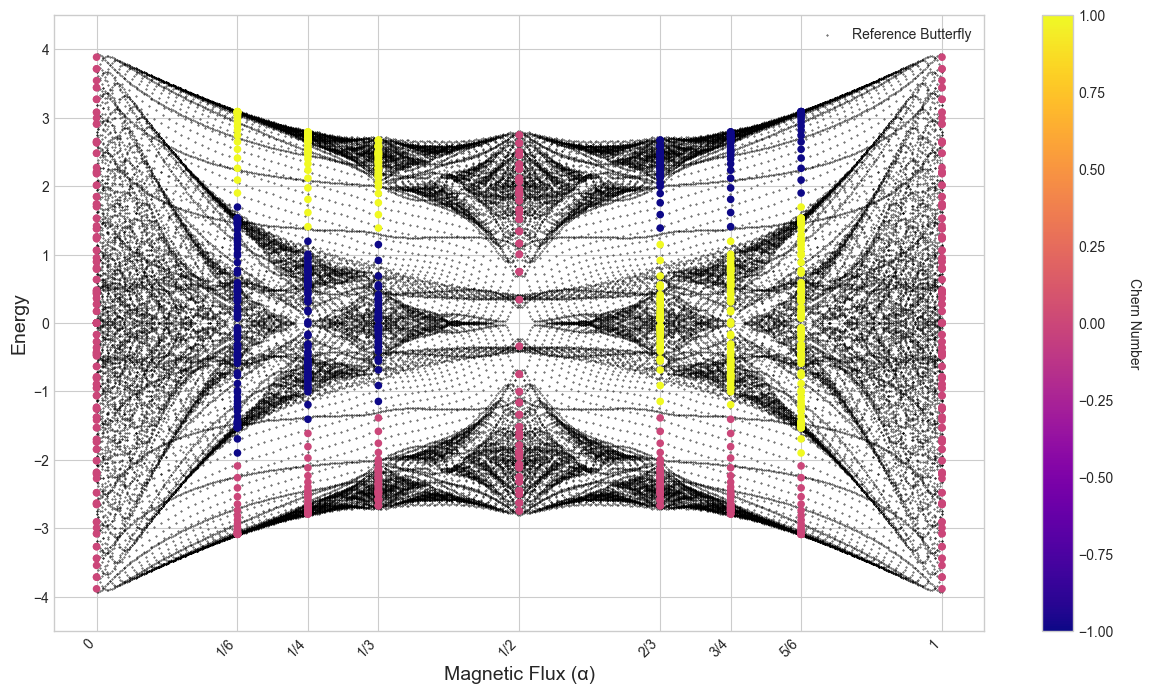

In [28]:


plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 8))


# This is plotted first, in black, as a fine-grained background.

plt.scatter(flux_array_hof, energy_array_hof, s=0.5, c='black', marker='.', label='Reference Butterfly')

# --- Calculated Data (Superimposed) ---

chern_array_mydata = chern_classes_mydata.flatten()


scatter_plot = ax.scatter(
    flux_array_mydata,
    energies_array_mydata,
    c=chern_array_mydata,      # Use the chern number array for color
    cmap='plasma',      # A perceptually uniform colormap
    s=20,
    alpha=1,
)

# --- Add and Label the Color Bar ---
cbar = fig.colorbar(scatter_plot, ax=ax)
cbar.set_label('Chern Number', rotation=270, labelpad=20)


#  Get the unique locations for the ticks from your flux data
tick_locations = np.unique(flux_array_mydata)

#  Create the fraction labels for each location
# The limit_denominator() method finds the nicest-looking fraction for a float.
tick_labels = [str(Fraction(f).limit_denominator()) for f in tick_locations]

# 3. Set the ticks and labels on the axis
ax.set_xticks(tick_locations)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=10) # Rotate labels to prevent overlap


# --- Final Touches for the Combined Plot ---
plt.xlabel("Magnetic Flux (α)", fontsize=14)
plt.ylabel("Energy", fontsize=14)
plt.ylim(-4.5, 4.5) # Keep the zoom
plt.legend()
plt.show()




#### Plot for OBC only of Chern number

This plot shouldn't have any physical meaning (at least, I have to try to understand that)
It is the Bott algorithm to copute the Chern number applied for every energy eigenstate. The algorithm should not make sense outside of gaps, yet we can see here hoe edge states have a integer number assignd and the others not

In [29]:
if PBC == False and single_cherns_plot_with_OBC:
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(15, 8))

    # This is plotted first, in black, as a fine-grained background.
    plt.scatter(flux_array_hof, energy_array_hof, s=0.5, c='black', marker='.', label='Reference Butterfly')

    # --- Calculated Data (Superimposed) ---
    single_cherns_OBC_array = single_cherns_OBC.flatten()

    scatter_plot = ax.scatter(
        flux_array_mydata,
        energies_array_mydata,
        c=single_cherns_OBC_array,      # Use the chern number array for color
        cmap='plasma',      # A perceptually uniform colormap
        s=20,
        alpha=1,
    )

    # --- Add and Label the Color Bar ---
    cbar = fig.colorbar(scatter_plot, ax=ax)
    cbar.set_label('Chern Number', rotation=270, labelpad=20)

    #  Get the unique locations for the ticks from your flux data
    tick_locations = np.unique(flux_array_mydata)

    #  Create the fraction labels for each location
    # The limit_denominator() method finds the nicest-looking fraction for a float.
    tick_labels = [str(Fraction(f).limit_denominator()) for f in tick_locations]

    # 3. Set the ticks and labels on the axis
    ax.set_xticks(tick_locations)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=10) # Rotate labels to prevent overlap

    # --- Final Touches for the Combined Plot ---
    plt.xlabel("Magnetic Flux (α)", fontsize=14)
    plt.ylabel("Energy", fontsize=14)
    plt.ylim(-4.5, 4.5) # Keep the zoom
    plt.legend()
    plt.show()

In [30]:
# H=get_hamiltonian_for_fixed_number_of_electrons(N=N, state_list=get_state_list(N=N, size=size), progress_bar=False)
# print("Hamiltonian H shape:", H.shape)

# print(tabulate(H, tablefmt="grid"))

In [31]:
# eigenvalues, eigenvectors=np.linalg.eigh(get_hamiltonian_for_fixed_number_of_electrons(N, PBC, T_y, T_x, p, q))
# for i in range(1, size**2-1): 
#     print(f"Chern number for {i} occupied states: {get_chern_number(i, eigenvectors)}", eigenvalues[i])

In [32]:
#this is to plot the ipr for a single flux value

# import numpy as np
# import matplotlib.pyplot as plt

# # Assuming get_hamiltonian_for_fixed_number_of_electrons is defined elsewhere
# eigenvalues, eigenvectors = np.linalg.eigh(get_hamiltonian_for_fixed_number_of_electrons(N, PBC, T_y, T_x, p, q))

# def calculate_IPR(vector):
#     """Calculate the Inverse Participation Ratio (IPR) of a vector."""
#     vector = np.abs(vector) ** 2
#     ipr = np.sum(vector ** 2)
#     return ipr

# # Sort eigenvalues and eigenvectors in ascending order of eigenvalues
# sorted_indices = np.argsort(eigenvalues)
# sorted_eigenvalues = eigenvalues[sorted_indices]
# sorted_eigenvectors = eigenvectors[:, sorted_indices]

# # Calculate IPR for each eigenvector
# ipr_values = [calculate_IPR(sorted_eigenvectors[:, i]) for i in range(sorted_eigenvectors.shape[1])]

# # Plot IPR vs Eigenvalues
# plt.figure(figsize=(8, 6))
# plt.plot(sorted_eigenvalues, ipr_values, marker='o', linestyle='-', color='b')
# plt.xlabel('Eigenvalue')
# plt.ylabel('IPR (Inverse Participation Ratio)')
# plt.title('IPR vs Eigenvalue')
# plt.grid(True)
# plt.show()